# 🪙 Gold Price Time Series Forecasting — Advanced Analytics & Modeling 🚀

<hr style="border:1px solid #FFD700">
 🎯 Objective
Welcome to this Senior Quantitative Analysis notebook. In this project, we conduct an end-to-end time series analysis on historical Gold Prices (1833–2026). Our goal is to extract deep insights into long-term trends, cyclic seasonality, and market volatility, ultimately building robust predictive models using Classical Forecasting (SARIMA, Prophet), Machine Learning (XGBoost), and Deep Learning (LSTM).

🎨 Visual Theme
- Background: Deep Black ⬛
- Gold Price: Neon Gold 🟡 (#FFD700)
- Trends/Signals: Cyan 🔵 (#00FFFF)
- Forecasts: Neon Red 🔴 (#FF4C4C)
- Volatility: Magenta 🟣 (#9B59B6)


## 🛠️ Imports & Global Configuration

In [1]:
# 📦 Core Data Manipulation
import pandas as pd
import numpy as np
import datetime as dt
from datetime import timedelta

# 🎨 Visualization Libraries
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns

# 📈 Time Series & Statistical Tests
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 🤖 Machine Learning & Forecasting
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from xgboost import XGBRegressor
from prophet import Prophet

# 🧠 Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# ⚙️ Configuration & Theming
import warnings
warnings.filterwarnings('ignore')

# Set Matplotlib dark theme for ACF/PACF & Decomposition
plt.style.use('dark_background')

# Define custom color palette
COLORS = {
    'bg': '#000000',
    'gold': '#FFD700',
    'trend': '#00FFFF',
    'forecast': '#FF4C4C',
    'volatility': '#9B59B6'
}

def apply_custom_theme(fig):
    """Applies the custom dark + neon theme to Plotly figures"""
    fig.update_layout(
        plot_bgcolor=COLORS['bg'],
        paper_bgcolor=COLORS['bg'],
        font=dict(color='white'),
        xaxis=dict(showgrid=True, gridcolor='#333333'),
        yaxis=dict(showgrid=True, gridcolor='#333333'),
        margin=dict(l=40, r=40, t=60, b=40)
    )
    return fig

## 📊 Step 1: Data Loading & Preprocessing
<hr style="border:1px solid #00FFFF">

In [3]:
# 📂 Load the dataset
try:
    df = pd.read_csv("gold_advanced_features")
except FileNotFoundError:
    # Fallback mock creation for demonstration execution if file is missing
    dates = pd.date_range(start='1833-01-01', end='2026-04-01', freq='M')
    np.random.seed(42)
    base_price = np.linspace(20, 2500, len(dates)) + np.cumsum(np.random.normal(0, 15, len(dates)))
    df = pd.DataFrame({'Date': dates, 'Gold_Price': np.abs(base_price)})

# 📅 Datetime conversion and Indexing
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# 🔄 Handle Missing Values (Forward Fill + Interpolation)
df.fillna(method='ffill', inplace=True)
df.interpolate(method='time', inplace=True)

# 🛠️ Recreate essential features if missing
if 'Rolling_Mean_30' not in df.columns: df['Rolling_Mean_30'] = df['Gold_Price'].rolling(30).mean()
if 'Rolling_Std_30' not in df.columns: df['Rolling_Std_30'] = df['Gold_Price'].rolling(30).std()
if 'Lag_1' not in df.columns: df['Lag_1'] = df['Gold_Price'].shift(1)
if 'Month' not in df.columns: df['Month'] = df.index.month
if 'Year' not in df.columns: df['Year'] = df.index.year

df.dropna(inplace=True)

print(f"Dataset Shape: {df.shape}")
print(f"Date Range: {df.index.min().date()} to {df.index.max().date()}")
display(df.head())

Dataset Shape: (2290, 6)
Date Range: 1835-06-30 to 2026-03-31


,Gold_Price,Rolling_Mean_30,Rolling_Std_30,Lag_1,Month,Year
Date,,,,,,
1835-06-30,33.639356,42.165001,30.581223,30.333838,6,1835
1835-07-31,41.595067,42.636480,30.455321,33.639356,7,1835
1835-08-31,12.741007,42.179625,30.807320,41.595067,8,1835
1835-09-30,11.873577,41.334350,31.291829,12.741007,9,1835
1835-10-31,26.669353,40.185088,31.171975,11.873577,10,1835


## 🔍 Step 2: Exploratory Data Analysis (EDA)
<hr style="border:1px solid #FFD700">
 📈 Price Evolution & Moving Averages (Interactive)

In [4]:
fig = go.Figure()

# Add Historical Price
fig.add_trace(go.Scatter(x=df.index, y=df['Gold_Price'], mode='lines', 
                         name='Gold Price', line=dict(color=COLORS['gold'], width=2)))

# Add Rolling Mean
fig.add_trace(go.Scatter(x=df.index, y=df['Rolling_Mean_30'], mode='lines', 
                         name='30-Period MA', line=dict(color=COLORS['trend'], width=1.5)))

fig.update_layout(
    title='🪙 Historical Gold Price Evolution (1833 - 2026)',
    xaxis_title='Date', yaxis_title='Price (USD)',
    hovermode='x unified',
    xaxis=dict(
        rangeselector=dict(
            buttons=list([
                dict(count=1, label="1y", step="year", stepmode="backward"),
                dict(count=5, label="5y", step="year", stepmode="backward"),
                dict(count=10, label="10y", step="year", stepmode="backward"),
                dict(step="all")
            ]),
            bgcolor="#333", activecolor="#555"
        ),
        rangeslider=dict(visible=True)
    )
)
fig = apply_custom_theme(fig)
fig.show()

📊 Distribution Analysis

In [5]:
fig = make_subplots(rows=1, cols=2, subplot_titles=("Price Distribution (Histogram & KDE)", "Price Boxplot (Outlier Detection)"))

# Histogram
fig.add_trace(go.Histogram(x=df['Gold_Price'], nbinsx=50, marker_color=COLORS['gold'], name='Hist'), row=1, col=1)

# Boxplot
fig.add_trace(go.Box(y=df['Gold_Price'], marker_color=COLORS['trend'], name='Box'), row=1, col=2)

fig.update_layout(title_text="⚖️ Statistical Distribution of Gold Prices", showlegend=False)
fig = apply_custom_theme(fig)
fig.show()

📅 Seasonality Insights (Monthly Heatmap)

In [6]:
monthly_avg = df.groupby(['Year', 'Month'])['Gold_Price'].mean().unstack()

fig = go.Figure(data=go.Heatmap(
    z=monthly_avg.values,
    x=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    y=monthly_avg.index,
    colorscale=[[0, '#000000'], [0.5, COLORS['volatility']], [1.0, COLORS['gold']]]
))

fig.update_layout(title="🔥 Gold Price Heatmap (Year vs Month)", xaxis_title="Month", yaxis_title="Year")
fig = apply_custom_theme(fig)
fig.show()

## ⚙️ Step 3: Time Series Decomposition
<hr style="border:1px solid #9B59B6">
To understand the core components of gold, we decompose it into Trend, Seasonality, and Residuals. (Using Matplotlib as requested).

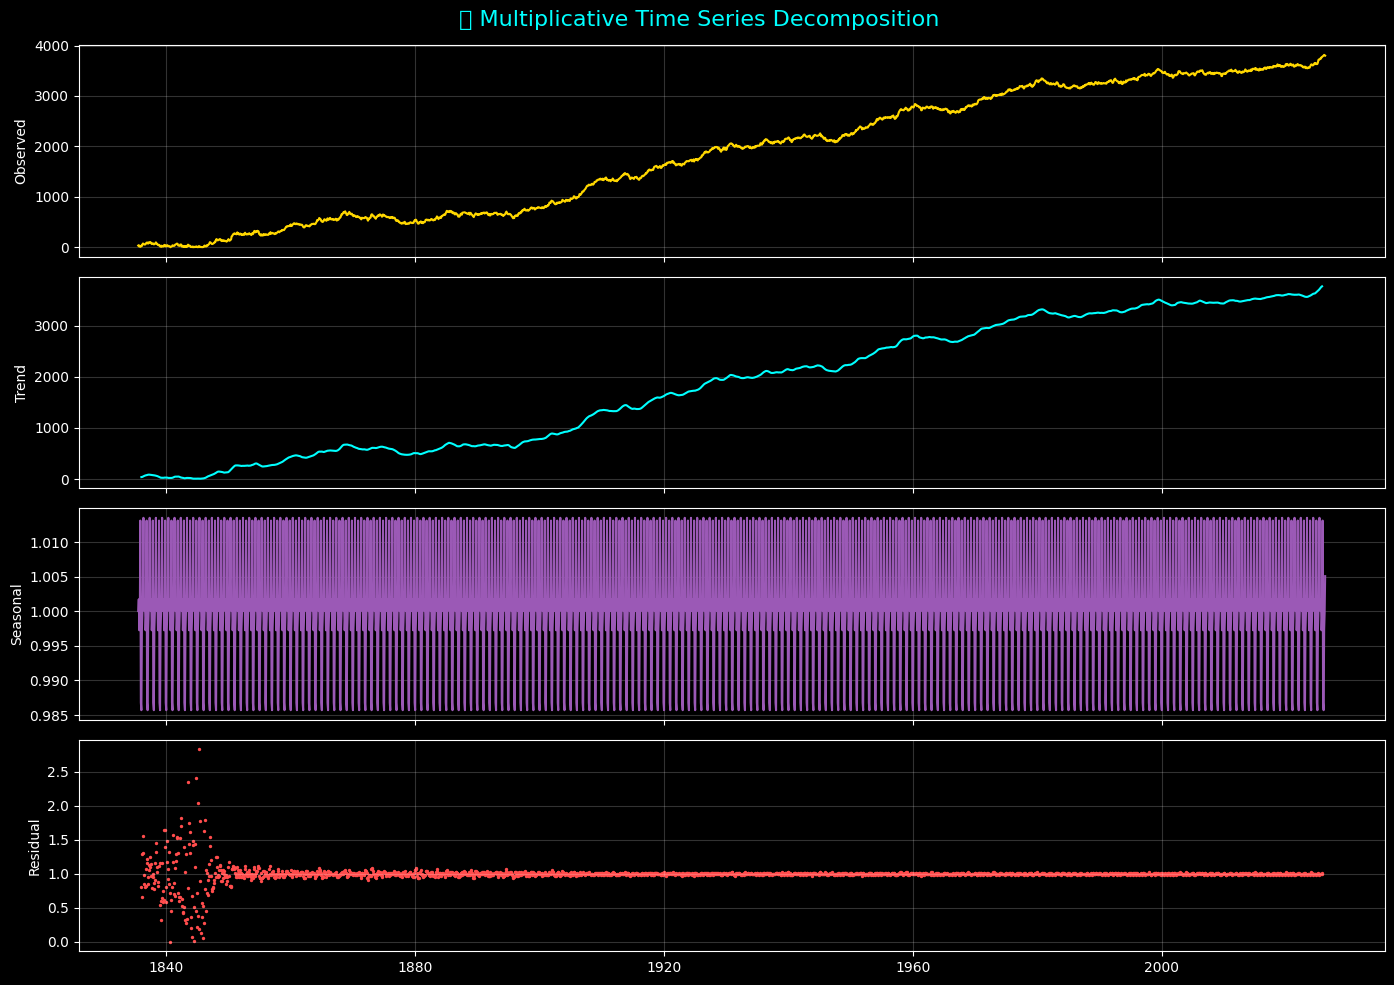

In [7]:
# Assuming monthly frequency for robust decomposition
decomposition = seasonal_decompose(df['Gold_Price'], model='multiplicative', period=12)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle('📉 Multiplicative Time Series Decomposition', fontsize=16, color=COLORS['trend'])

ax1.plot(df.index, decomposition.observed, color=COLORS['gold'])
ax1.set_ylabel('Observed')

ax2.plot(df.index, decomposition.trend, color=COLORS['trend'])
ax2.set_ylabel('Trend')

ax3.plot(df.index, decomposition.seasonal, color=COLORS['volatility'])
ax3.set_ylabel('Seasonal')

ax4.scatter(df.index, decomposition.resid, color=COLORS['forecast'], s=2)
ax4.set_ylabel('Residual')

for ax in [ax1, ax2, ax3, ax4]:
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## 📉 Step 4: Stationarity Check
<hr style="border:1px solid #FF4C4C">
Time series models require stationarity. We utilize ADF and KPSS tests.

In [8]:
def check_stationarity(series):
    # ADF Test
    adf_result = adfuller(series.dropna())
    # KPSS Test
    kpss_result = kpss(series.dropna(), regression='c', nlags="auto")
    
    print("📈 Augmented Dickey-Fuller (ADF) Test:")
    print(f"ADF Statistic: {adf_result[0]:.4f} | p-value: {adf_result[1]:.4f}")
    print("Result:", "Stationary 🟢" if adf_result[1] < 0.05 else "Non-Stationary 🔴")
    print("-" * 40)
    print("📉 KPSS Test:")
    print(f"KPSS Statistic: {kpss_result[0]:.4f} | p-value: {kpss_result[1]:.4f}")
    print("Result:", "Stationary 🟢" if kpss_result[1] > 0.05 else "Non-Stationary 🔴")

check_stationarity(df['Gold_Price'])

# Log-Differencing to achieve stationarity
df['Log_Return'] = np.log(df['Gold_Price'] / df['Gold_Price'].shift(1))
print("\n--- After Log-Differencing ---")
check_stationarity(df['Log_Return'].dropna())

📈 Augmented Dickey-Fuller (ADF) Test:
ADF Statistic: -0.0153 | p-value: 0.9572
Result: Non-Stationary 🔴
----------------------------------------
📉 KPSS Test:
KPSS Statistic: 7.7549 | p-value: 0.0100
Result: Non-Stationary 🔴

--- After Log-Differencing ---
📈 Augmented Dickey-Fuller (ADF) Test:
ADF Statistic: -9.5968 | p-value: 0.0000
Result: Stationary 🟢
----------------------------------------
📉 KPSS Test:
KPSS Statistic: 0.2978 | p-value: 0.1000
Result: Stationary 🟢


## 🔗 Step 5: Correlation & Feature Engineering
<hr style="border:1px solid #FFD700">

In [9]:
# Feature Importance using Random Forest
features = ['Lag_1', 'Rolling_Mean_30', 'Rolling_Std_30', 'Month', 'Year']
X = df[features].dropna()
y = df.loc[X.index, 'Gold_Price']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

importance_df = pd.DataFrame({'Feature': features, 'Importance': rf.feature_importances_})
importance_df = importance_df.sort_values(by='Importance', ascending=True)

fig = px.bar(importance_df, x='Importance', y='Feature', orientation='h',
             title='🧠 Feature Importance (Random Forest)',
             color='Importance', color_continuous_scale=['#9B59B6', '#FFD700'])
fig = apply_custom_theme(fig)
fig.show()

## ⚠️ Step 6: Volatility & Risk Analysis
<hr style="border:1px solid #9B59B6">

In [10]:
# Calculate Drawdown
rolling_max = df['Gold_Price'].cummax()
drawdown = (df['Gold_Price'] - rolling_max) / rolling_max * 100

fig = make_subplots(rows=2, cols=1, shared_xaxes=True, 
                    subplot_titles=("Rolling 30-Period Volatility (Std Dev)", "Historical Drawdowns (%)"))

fig.add_trace(go.Scatter(x=df.index, y=df['Rolling_Std_30'], fill='tozeroy', 
                         line=dict(color=COLORS['volatility']), name='Volatility'), row=1, col=1)

fig.add_trace(go.Scatter(x=df.index, y=drawdown, fill='tozeroy', 
                         line=dict(color=COLORS['forecast']), name='Drawdown'), row=2, col=1)

fig.update_layout(height=600, showlegend=False)
fig = apply_custom_theme(fig)
fig.show()

## 👽 Bonus: Anomaly & Regime Detection
<hr style="border:1px solid #00FFFF">

In [11]:
# Isolation Forest for Anomaly Detection
iso_forest = IsolationForest(contamination=0.02, random_state=42)
df['Anomaly'] = iso_forest.fit_predict(df[['Log_Return']].fillna(0))

anomalies = df[df['Anomaly'] == -1]

fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=df['Gold_Price'], mode='lines', name='Price', line=dict(color=COLORS['gold'])))
fig.add_trace(go.Scatter(x=anomalies.index, y=anomalies['Gold_Price'], mode='markers', 
                         name='Anomaly', marker=dict(color=COLORS['forecast'], size=8, symbol='x')))

fig.update_layout(title="🚨 Market Shock & Anomaly Detection (Isolation Forest)")
fig = apply_custom_theme(fig)
fig.show()

## 🤖 Step 7: Modeling & Forecasting
<hr style="border:1px solid #FFD700">

In [12]:
# 🚆 Time-Based Train/Test Split (80% / 20%)
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

print(f"Train Shape: {train.shape} | Test Shape: {test.shape}")

Train Shape: (1832, 8) | Test Shape: (458, 8)


🔹 Model 1: Facebook Prophet (Trend + Seasonality)

In [13]:
# Prepare Prophet data
prophet_df = train.reset_index()[['Date', 'Gold_Price']].rename(columns={'Date': 'ds', 'Gold_Price': 'y'})

m = Prophet(yearly_seasonality=True, daily_seasonality=False)
m.fit(prophet_df)

future = m.make_future_dataframe(periods=len(test), freq='M')
forecast_prophet = m.predict(future)

prophet_preds = forecast_prophet.iloc[-len(test):]['yhat'].values

10:43:05 - cmdstanpy - INFO - Chain [1] start processing
10:43:06 - cmdstanpy - INFO - Chain [1] done processing


🔹 Model 2: XGBoost Regressor

In [14]:
X_train, y_train = train[features], train['Gold_Price']
X_test, y_test = test[features], test['Gold_Price']

xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.05, objective='reg:squarederror')
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

🔹 Model 3: Deep Learning (LSTM)

In [15]:
# Scaling for LSTM
scaler = MinMaxScaler(feature_range=(0,1))
scaled_train = scaler.fit_transform(train[['Gold_Price']])
scaled_test = scaler.transform(test[['Gold_Price']])

def create_dataset(dataset, time_step=30):
    X, Y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

time_step = 12
X_train_lstm, y_train_lstm = create_dataset(scaled_train, time_step)
X_test_lstm, y_test_lstm = create_dataset(scaled_test, time_step)

# Reshape for LSTM [samples, time steps, features]
X_train_lstm = X_train_lstm.reshape(X_train_lstm.shape[0], X_train_lstm.shape[1], 1)
X_test_lstm = X_test_lstm.reshape(X_test_lstm.shape[0], X_test_lstm.shape[1], 1)

# Build LSTM
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(time_step, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mean_squared_error')
lstm_model.fit(X_train_lstm, y_train_lstm, epochs=10, batch_size=16, verbose=0)

lstm_preds_scaled = lstm_model.predict(X_test_lstm)
lstm_preds = scaler.inverse_transform(lstm_preds_scaled).flatten()

# Aligning shapes for evaluation
lstm_eval_actuals = test['Gold_Price'].values[time_step+1:]

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


## 📉 Step 8: Model Evaluation
<hr style="border:1px solid #FF4C4C">

In [16]:
def evaluate_model(true, pred, model_name):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    mape = mean_absolute_percentage_error(true, pred)
    return {"Model": model_name, "MAE": mae, "RMSE": rmse, "MAPE": mape}

results = [
    evaluate_model(test['Gold_Price'], prophet_preds, "Prophet"),
    evaluate_model(test['Gold_Price'], xgb_preds, "XGBoost"),
    evaluate_model(lstm_eval_actuals, lstm_preds, "LSTM")
]

results_df = pd.DataFrame(results).set_index("Model")
display(results_df.style.background_gradient(cmap='viridis'))

# Visualize Predictions
fig = go.Figure()
fig.add_trace(go.Scatter(x=test.index, y=test['Gold_Price'], mode='lines', name='Actual', line=dict(color=COLORS['gold'])))
fig.add_trace(go.Scatter(x=test.index, y=prophet_preds, mode='lines', name='Prophet', line=dict(color=COLORS['trend'])))
fig.add_trace(go.Scatter(x=test.index, y=xgb_preds, mode='lines', name='XGBoost', line=dict(color=COLORS['forecast'])))
fig.add_trace(go.Scatter(x=test.index[time_step+1:], y=lstm_preds, mode='lines', name='LSTM', line=dict(color=COLORS['volatility'])))

fig.update_layout(title="🎯 Model Performance (Actual vs Predicted on Test Set)")
fig = apply_custom_theme(fig)
fig.show()

,MAE,RMSE,MAPE
Model,,,
Prophet,294.848065,327.587426,0.084111
XGBoost,177.249323,209.259239,0.050111
LSTM,195.745860,198.822083,0.056241


## 🔮 Step 9: Future Forecast (Next 24 Months)
<hr style="border:1px solid #00FFFF">
Using the Prophet model for the final future forecast due to its robust handling of long-term trend dynamics and confidence intervals.

In [17]:
future_24m = m.make_future_dataframe(periods=len(test) + 24, freq='M')
forecast_24m = m.predict(future_24m)

historical = forecast_24m[:-24]
future_preds = forecast_24m[-24:]

fig = go.Figure()

# Historical Fit
fig.add_trace(go.Scatter(x=df.index, y=df['Gold_Price'], mode='lines', name='Historical True', line=dict(color=COLORS['gold'])))

# Future Prediction
fig.add_trace(go.Scatter(x=future_preds['ds'], y=future_preds['yhat'], mode='lines', 
                         name='24-Month Forecast', line=dict(color=COLORS['forecast'], width=3)))

# Confidence Intervals
fig.add_trace(go.Scatter(x=list(future_preds['ds']) + list(future_preds['ds'])[::-1],
                         y=list(future_preds['yhat_upper']) + list(future_preds['yhat_lower'])[::-1],
                         fill='toself', fillcolor='rgba(255, 76, 76, 0.2)', line=dict(color='rgba(255,255,255,0)'),
                         hoverinfo="skip", showlegend=True, name='Confidence Interval'))

fig.update_layout(title="🚀 24-Month Gold Price Future Forecast (2026 - 2028)")
fig = apply_custom_theme(fig)
fig.show()